MIT-BIH Arrhythmia Database : La base de données sur les arythmies du MIT-BIH contient 48 extraits d'une demi-heure d'enregistrements ECG ambulatoires à deux canaux, provenant de 47 sujets étudiés par le laboratoire d'arythmie du BIH entre 1975 et 1979. Vingt-trois enregistrements ont été choisis au hasard parmi un ensemble de 4 000 enregistrements ECG ambulatoires de 24 heures recueillis auprès d'une population mixte de patients hospitalisés (environ 60 %) et de patients ambulatoires (environ 40 %) à l'hôpital Beth Israel de Boston ; les 25 enregistrements restants ont été sélectionnés dans le même ensemble afin d'inclure des arythmies moins courantes mais cliniquement significatives qui ne seraient pas bien représentées dans un petit échantillon aléatoire.

Lien dataset : https://physionet.org/content/mitdb/1.0.0/#files-panel

## Pipeline : 

## - Données brutes MIT-BIH
## - Augmentation : bruit gaussien + scaling
## - SSL - SimCLRModel : NT-Xent loss sur paires (z1, z2)
## - Encodeur pré-entraîné - représentations h        
## - LinearProbe
## - FineTunedModel

Donc pipeline en 2 phases : 

**Phase 1 — Self-Supervised Learning (SSL)**
L'encodeur TCN est pré-entraîné sans labels via SimCLR :

On prend un signal ECG, on crée 2 vues augmentées (x1, x2)
L'objectif est que les représentations z1 et z2 du même signal soient proches, et éloignées des autres signaux du batch
La NT-Xent loss guide ça — aucun label de classe n'est utilisé

**Phase 2 — Supervised Learning**
On prend l'encodeur pré-entraîné et on l'évalue/affine avec les labels :

Linear Probing : on gèle l'encodeur, on entraîne juste une couche linéaire → supervisé minimal
Fine-tuning : on dégeèle tout et on entraîne avec les 5 classes → supervisé complet
Baseline : un TCN entraîné from scratch, 100% supervisé, sans pré-entraînement SSL


# 1 - Import

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import random

SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# Hyperparamètres globaux 
CONFIG = {
    # Données
    "n_classes"     : 5,
    "signal_length" : 187,

    # SSL - SimCLR
    "temperature"   : 0.5,
    "ssl_epochs"    : 100,
    "ssl_lr"        : 3e-3,
    "ssl_batch_size": 256,

    # Modèle
    "d_model"       : 128,   # dimension des représentations h
    "proj_dim"      : 64,    # dimension de la projection z

    # TCN
    "tcn_channels"  : 64,
    "tcn_layers"    : 7,
    "tcn_kernel"    : 3,

    # PatchTST -- non utilisé ici 
    "patch_size"    : 16,
    "patch_stride"  : 8,
    "n_heads"       : 4,
    "n_layers"      : 3,

    # Fine-tuning
    "ft_epochs"     : 50,
    "ft_lr"         : 1e-4,
    "ft_batch_size" : 256,
}

Device : cuda


In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path_train = "mitbih_train.csv"
file_path_test = "mitbih_test.csv"

# Load the latest version
train_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shayanfazeli/heartbeat",
  file_path_train,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
# Load the latest version
test_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shayanfazeli/heartbeat",
  file_path_test,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", train_df.head())

/tmp/ipykernel_55/858245359.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  train_df = kagglehub.load_dataset(
/tmp/ipykernel_55/858245359.py:21: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  test_df = kagglehub.load_dataset(


First 5 records:    9.779411554336547852e-01  9.264705777168273926e-01  \
0                  0.960114                  0.863248   
1                  1.000000                  0.659459   
2                  0.925414                  0.665746   
3                  0.967136                  1.000000   
4                  0.927461                  1.000000   

   6.813725233078002930e-01  2.450980395078659058e-01  \
0                  0.461538                  0.196581   
1                  0.186486                  0.070270   
2                  0.541436                  0.276243   
3                  0.830986                  0.586854   
4                  0.626943                  0.193437   

   1.544117629528045654e-01  1.911764740943908691e-01  \
0                  0.094017                  0.125356   
1                  0.070270                  0.059459   
2                  0.196133                  0.077348   
3                  0.356808                  0.248826   
4           

In [5]:
# Renommage des colonnes
n_cols = train_df.shape[1]
col_names = [f"t_{i}" for i in range(n_cols - 1)] + ["label"]

train_df.columns = col_names
test_df.columns  = col_names

# Séparation features / labels
X_train = train_df.iloc[:, :-1].values.astype(np.float32)
y_train = train_df.iloc[:, -1].values.astype(np.int64)

X_test  = test_df.iloc[:, :-1].values.astype(np.float32)
y_test  = test_df.iloc[:, -1].values.astype(np.int64)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Classes train : {Counter(y_train)}")
print(f"Classes test  : {Counter(y_test)}")

Train : (87553, 187) | Test : (21891, 187)
Classes train : Counter({np.int64(0): 72470, np.int64(4): 6431, np.int64(2): 5788, np.int64(1): 2223, np.int64(3): 641})
Classes test  : Counter({np.int64(0): 18117, np.int64(4): 1608, np.int64(2): 1448, np.int64(1): 556, np.int64(3): 162})


# 2 - Partie Visualisation de pré-traitement

On a la répartition suivante des classes : 

- Classe 0 : 72470 Normal
- Classe 1 : 2223 Supra
- Classe 2 : 5788 Ventricular
- Classe 3 : 641 Fusion
- Classe 4 : 6431 Inconnu

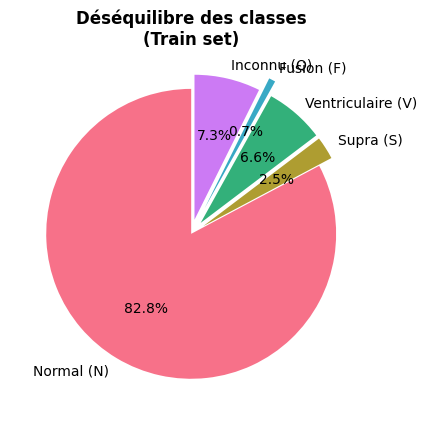

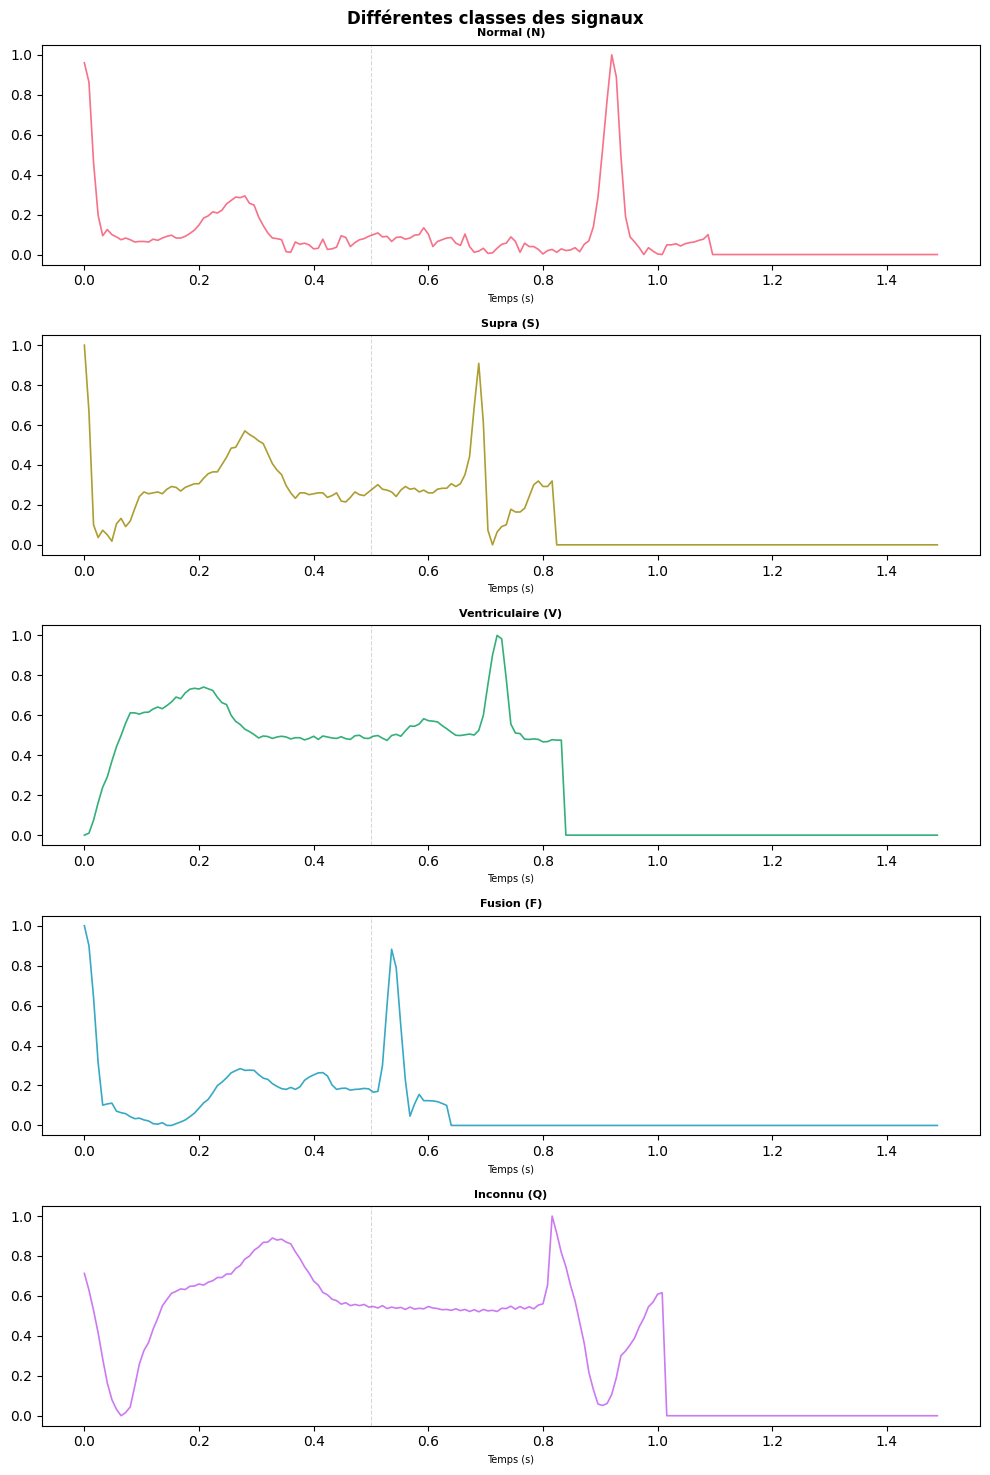

In [55]:

fig = plt.figure(figsize=(20, 16))
CLASS_LABELS = [CLASS_NAMES[i] for i in range(5)]
COLORS = sns.color_palette("husl", 5)

# Camembert du déséquilibre 
ax1 = fig.add_subplot(3, 3, 1)
counts = [np.sum(y_train == i) for i in range(5)]
explode = [0, 0.1, 0.1, 0.2, 0.1]  
ax1.pie(counts, labels=CLASS_LABELS, colors=COLORS,
        autopct='%1.1f%%', explode=explode, startangle=90)
ax1.set_title("Déséquilibre des classes\n(Train set)", fontweight='bold')


# Figure de chaque classe
fig, axes = plt.subplots(5, 1, figsize=(10, 15))
time_axis = np.arange(187) / 125

for cls in range(5):
    idx = np.where(y_train == cls)[0][0]
    axes[cls].plot(time_axis, X_train[idx],
                         color=COLORS[cls], linewidth=1.2)
    axes[cls].set_title(f"{CLASS_LABELS[cls]}", fontsize=8, fontweight='bold')
    axes[cls].set_xlabel("Temps (s)", fontsize=7)
    axes[cls].axvline(x=0.5, color='gray', linestyle='--',
                             alpha=0.3, linewidth=0.8)  # repère temporel

plt.suptitle("Différentes classes des signaux", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



# 3 - Data Augmentation 

On applique ici : 
- **Bruit gaussien.** Justification clinique solide : simule le bruit électronique des électrodes, les artefacts musculaires (EMG), ou une mauvaise conduction cutanée.
- **Scaling d'amplitude.** Justification clinique solide : simule la variabilité du placement des électrodes et les différences d'impédance entre patients. C'est exactement le type de variabilité inter-patient qu'on veut que le modèle ignore.
- **Window Warping.** Justification clinique solide : simule la variabilité naturelle du rythme cardiaque (variabilité de la fréquence cardiaque). Un même type de battement peut être légèrement plus rapide ou plus lent selon l'état du patient
- **Baseline Wander** : une dérive lente sinusoïdale qui simule les artefacts respiratoires 



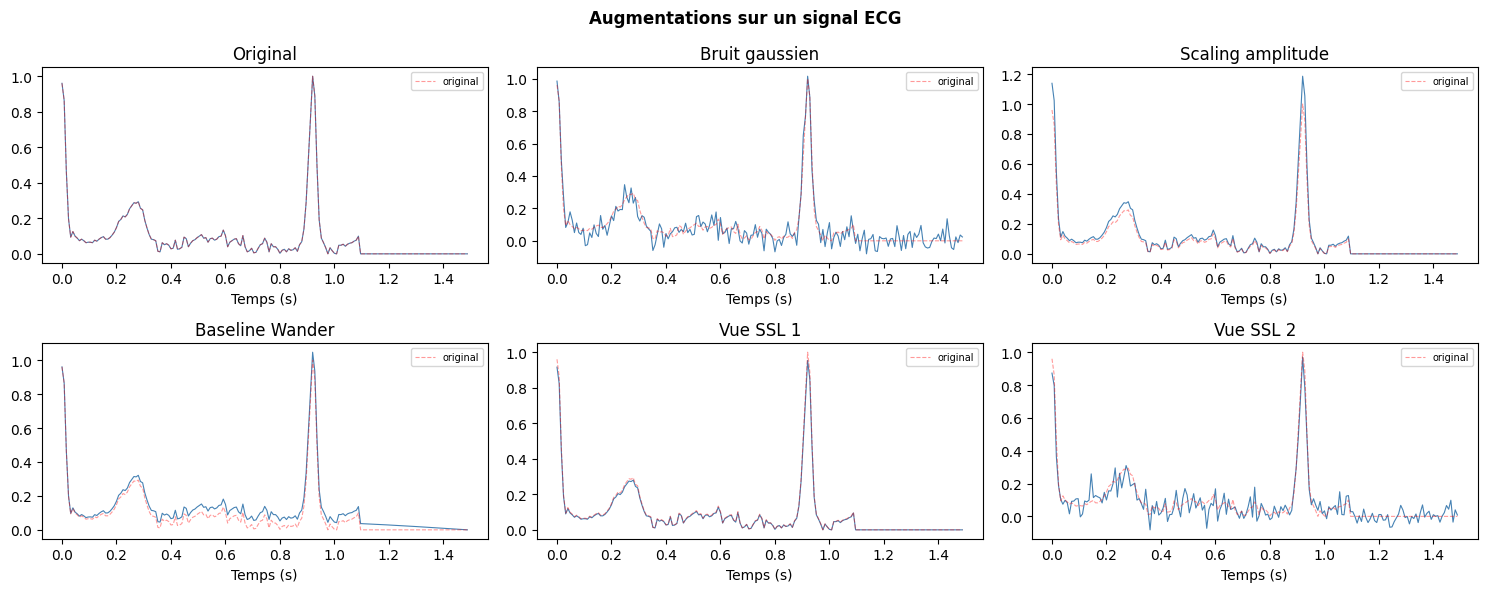

In [6]:
def gaussian_noise(signal, std=0.05):
    noise = np.random.normal(0, std, size=signal.shape)
    return signal + noise

def amplitude_scaling(signal, min_scale=0.8, max_scale=1.2):
    scale = np.random.uniform(min_scale, max_scale)
    return signal * scale

'''
def window_warping(signal, window_ratio=0.2, warp_factor=2):
    length = len(signal)
    
    # On limite la fenêtre à la première moitié du signal
    max_start = length // 2
    window_size = int(length * 0.15)  # fenêtre de 15% du signal
    start = np.random.randint(0, max_start - window_size)
    window = signal[start:start + window_size]
    
    # Accélère ou ralentit par warp_factor
    if np.random.rand() > 0.5:
        # Accélération : on compresse la fenêtre
        warped = np.interp(
            np.linspace(0, len(window)-1, len(window)//warp_factor),
            np.arange(len(window)),
            window
        )
        new_signal = np.concatenate([
            signal[:start],
            warped,
            signal[start + window_size:]
        ])
    else:
        # Ralentissement : on étire la fenêtre
        warped = np.interp(
            np.linspace(0, len(window)-1, len(window)*warp_factor),
            np.arange(len(window)),
            window
        )
        new_signal = np.concatenate([
            signal[:start],
            warped,
            signal[start + window_size:]
        ])
    
    # Recadrage à la longueur originale
    if len(new_signal) < length:
        new_signal = np.pad(new_signal, (0, length - len(new_signal)))
    else:
        new_signal = new_signal[:length]
    
    return new_signal.astype(np.float32)
'''

def baseline_wander(signal, frequency=0.5, amplitude=0.05):
    length = len(signal)
    t = np.linspace(0, 1, length)
    wander = amplitude * np.sin(2 * np.pi * frequency * t)
    return (signal + wander).astype(np.float32)

def augment_signal(signal, p=0.5): # Applique chaque augmentation avec probabilité p
    if np.random.rand() < p:
        signal = gaussian_noise(signal)
    if np.random.rand() < p:
        signal = amplitude_scaling(signal)
    if np.random.rand() < p:
        signal = baseline_wander(signal)
    return signal

# Test visuel 
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

example = X_train[0]  # un signal Normal

transforms = [
    ("Original",          lambda x: x),
    ("Bruit gaussien",    gaussian_noise),
    ("Scaling amplitude", amplitude_scaling),
    ("Baseline Wander",    baseline_wander),
    ("Vue SSL 1",         augment_signal),
    ("Vue SSL 2",         augment_signal),
]

time_axis = np.arange(187) / 125

for ax, (title, fn) in zip(axes.flatten(), transforms):
    ax.plot(time_axis, fn(example.copy()), color="steelblue", linewidth=0.8)
    ax.plot(time_axis, example, color="red", linewidth=0.8,
            alpha=0.4, linestyle="--", label="original")
    ax.set_title(title)
    ax.set_xlabel("Temps (s)")
    ax.legend(fontsize=7)

plt.suptitle("Augmentations sur un signal ECG", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 4 - Rééquilibrage des classes

- **Undersampling de la classe majoritaire**, à utiliser avec modération pour ne pas perdre trop d’information
- **Data augmentation sur les classes minoritaires ='oversampling.**
    - SMOTE (génération de nouveaux exemples synthétiques par interpolation). 
    - Sur des signaux ECG, on peut aussi augmenter en ajoutant du bruit gaussien, en scalant l'amplitude, ou en faisant du warping temporel
La combinaison des deux s'appelle une stratégie hybrid resampling — c'est le standard en pratique. Attention : la data augmentation ne se fait que sur le dataset train, pour éviter le data leakage.

## Choix de la taille 

Classe majoritaire : N avec 72470
Classe minoritaire : F avec 641 classes
Si on augmente à 20,000 effectifs par classe, on doit multiplier F par 31, ce qui est trop sachant qu’on a que 3 augmentations, on risque de faire du surapprentissage
**Si on augmente à 5,000 effectifs par classe, on doit multiplier F par 8, ce qui est plus raisonnable.**

## Shuffle 

On doit faire un shuffle : Sans shuffle, les premiers batches contiennent uniquement la classe 0, les suivants uniquement la classe 1, etc. Le modèle apprend un biais d'ordre et la loss oscille violemment. Ce n'est pas représentatif de la distribution réelle.


Classe 0 : 72470 → 5000 (undersampling)
Classe 1 : 2223 → 5000 (oversampling)
Classe 2 : 5788 → 5000 (undersampling)
Classe 3 : 641 → 5000 (oversampling)
Classe 4 : 6431 → 5000 (undersampling)

Dataset final : (25000, 187)
Distribution : Counter({np.int64(3): 5000, np.int64(0): 5000, np.int64(4): 5000, np.int64(2): 5000, np.int64(1): 5000})


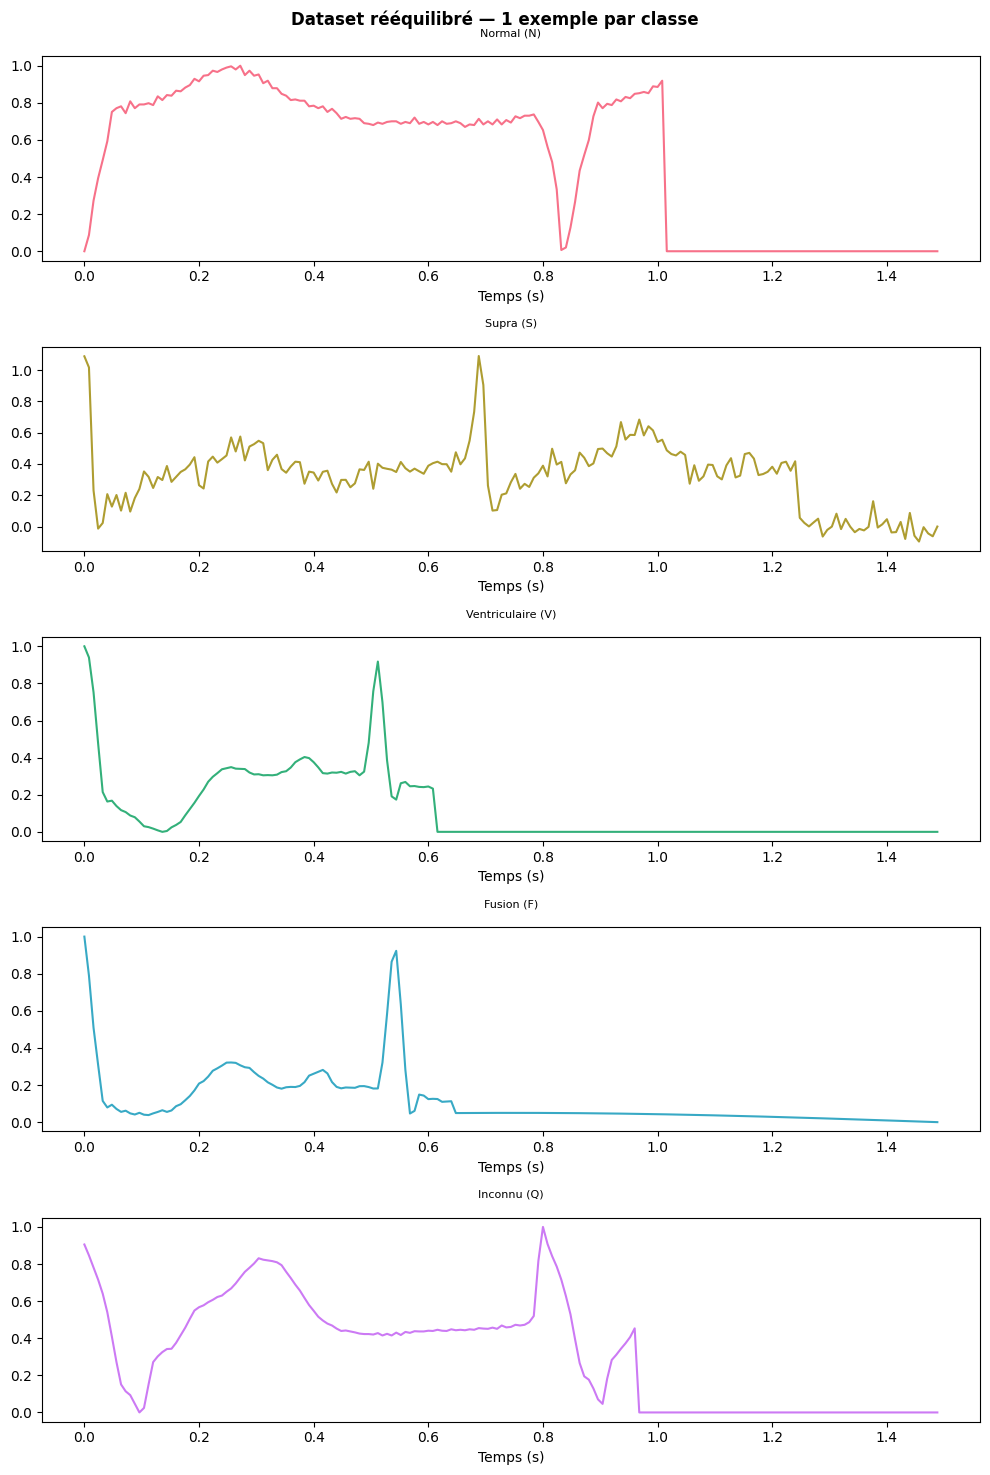

In [60]:
TARGET = 5000
CLASS_NAMES = [0,1,2,3,4]

CLASS_NAMES = {
    0: "Normal (N)",
    1: "Supra (S)", 
    2: "Ventriculaire (V)",
    3: "Fusion (F)",
    4: "Inconnu (Q)"
}

def oversample_class(X, y, target_class, target_n): # Génère des exemples synthétiques pour une classe minoritaire
    X_class = X[y == target_class]
    n_original = len(X_class)
    n_to_generate = target_n - n_original
    
    synthetic = []
    for _ in range(n_to_generate):
        # Tire un signal original aléatoirement
        idx = np.random.randint(0, n_original)
        augmented = augment_signal(X_class[idx].copy())
        synthetic.append(augmented)
    
    X_synthetic = np.array(synthetic, dtype=np.float32)
    y_synthetic = np.full(len(synthetic), target_class, dtype=np.int64)
    
    return X_synthetic, y_synthetic

def undersample_class(X, y, target_class, target_n): # Sous-échantillonne une classe majoritaire
    X_class = X[y == target_class]
    idx = np.random.choice(len(X_class), target_n, replace=False)
    return X_class[idx], np.full(target_n, target_class, dtype=np.int64)

# Rééquilibrage 
X_balanced_list = []
y_balanced_list = []

for cls in range(5):
    n_cls = np.sum(y_train == cls)
    
    if n_cls > TARGET:
        # Undersampling
        X_cls, y_cls = undersample_class(X_train, y_train, cls, TARGET)
        print(f"Classe {cls} : {n_cls} → {TARGET} (undersampling)")
    else:
        # On garde les originaux
        X_cls_orig = X_train[y_train == cls]
        y_cls_orig = y_train[y_train == cls]
        
        # On génère les synthétiques
        X_syn, y_syn = oversample_class(X_train, y_train, cls, TARGET)
        
        X_cls = np.concatenate([X_cls_orig, X_syn])
        y_cls = np.concatenate([y_cls_orig, y_syn])
        print(f"Classe {cls} : {n_cls} → {len(X_cls)} (oversampling)")
    
    X_balanced_list.append(X_cls)
    y_balanced_list.append(y_cls)

X_balanced = np.concatenate(X_balanced_list).astype(np.float32)
y_balanced = np.concatenate(y_balanced_list).astype(np.int64)

# Shuffle
shuffle_idx = np.random.permutation(len(X_balanced))
X_balanced = X_balanced[shuffle_idx]
y_balanced = y_balanced[shuffle_idx]

print(f"\nDataset final : {X_balanced.shape}")
print(f"Distribution : {Counter(y_balanced)}")

# Exemple visuel 
fig, axes = plt.subplots(5, 1, figsize=(10, 15))
time_axis = np.arange(187) / 125

for cls in range(5):
    idx = np.where(y_balanced == cls)[0][0]
    axes[cls].plot(time_axis, X_balanced[idx],
                   color=sns.color_palette("husl", 5)[cls])
    axes[cls].set_title(f"{CLASS_NAMES[cls]}\n", fontsize=8)
    axes[cls].set_xlabel("Temps (s)")

plt.suptitle("Dataset rééquilibré — 1 exemple par classe",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



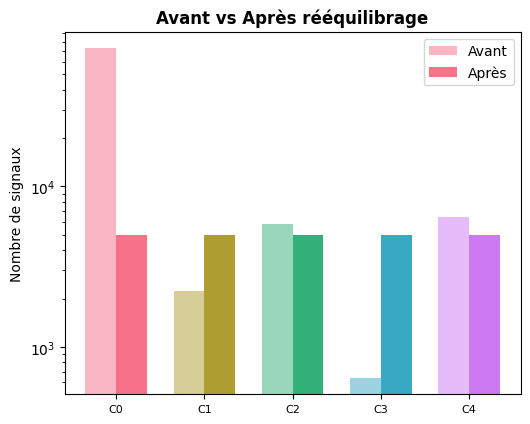

In [48]:
fig = plt.figure(figsize=(20, 16))

# Barplot avant/après rééquilibrage 
ax = fig.add_subplot(3, 3, 2)
x = np.arange(5)
width = 0.35
bars1 = ax.bar(x - width/2, counts, width, label='Avant', color=COLORS, alpha=0.5)
bars2 = ax.bar(x + width/2, [5000]*5, width, label='Après', color=COLORS)
ax.set_xticks(x)
ax.set_xticklabels([f"C{i}" for i in range(5)], fontsize=8)
ax.set_ylabel("Nombre de signaux")
ax.set_title("Avant vs Après rééquilibrage", fontweight='bold')
ax.legend()
ax.set_yscale('log')


# 5 - Dataset et DataLoader

## Split 

On fait un split avec un argument stratufy = y_balanced, pour que chaque classe soit bien représentée dans la séparation. 

## Augmentation uniquement sur le train

On ne veut pas d'augmentation sur la validation ou le test --> éviter le data leakage, donc d'avoir des copies du même signal dans le train et le test.

In [9]:
class ECGSSLDataset(Dataset):
    """Dataset pour le pré-entraînement SSL — retourne 2 vues augmentées."""
    
    def __init__(self, X):
        self.X = X
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        signal = self.X[idx]
        x1 = torch.tensor(augment_signal(signal.copy()), dtype=torch.float32)
        x2 = torch.tensor(augment_signal(signal.copy()), dtype=torch.float32)
        return x1, x2


class ECGSupervisedDataset(Dataset):
    """Dataset pour le fine-tuning supervisé — retourne signal + label."""
    
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment  # True pour le train, False pour val/test
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        signal = self.X[idx]
        if self.augment:
            signal = augment_signal(signal.copy())
        x = torch.tensor(signal, dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


# Split train/val sur X_balanced 
X_tr, X_val, y_tr, y_val = train_test_split(
    X_balanced, y_balanced,
    test_size=0.15,
    random_state=SEED,
    stratify=y_balanced 
)

print(f"Train   : {X_tr.shape} | Val : {X_val.shape}")


ssl_dataset   = ECGSSLDataset(X_tr)
train_dataset = ECGSupervisedDataset(X_tr,   y_tr,   augment=True)
val_dataset   = ECGSupervisedDataset(X_val,  y_val,  augment=False)
test_dataset  = ECGSupervisedDataset(X_test, y_test, augment=False)

# DataLoaders
ssl_loader   = DataLoader(ssl_dataset,   batch_size=CONFIG["ssl_batch_size"],
                          shuffle=True,  num_workers=2, pin_memory=True)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["ft_batch_size"],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["ft_batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["ft_batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"SSL batches     : {len(ssl_loader)}")
print(f"Train batches   : {len(train_loader)}")
print(f"Val batches     : {len(val_loader)}")
print(f"Test batches    : {len(test_loader)}")

Train   : (21250, 187) | Val : (3750, 187)
SSL batches     : 84
Train batches   : 84
Val batches     : 15
Test batches    : 86


# 6 - Model TCN

Pour un TCN, on doit choisir le nombre de couches, le kernel k. Comme on a 188 points par signal et que la formule du receptive field est de : Receptive field = 2L * (k-1) + 1, on va choisir : 
- k = 3
- L = 7 (6 alors Rf = 127, 7 alors Rf = 255, ce qui recouvre tout le signal)

On prend LayerNorm pour normaliser.


In [61]:
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        
        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            dilation=dilation, padding=self.padding
        )
        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            dilation=dilation, padding=self.padding
        )
        
        self.norm1  = nn.LayerNorm(out_channels)
        self.norm2  = nn.LayerNorm(out_channels)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        self.residual = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.kaiming_normal_(self.conv1.weight)
        nn.init.kaiming_normal_(self.conv2.weight)
    
    def forward(self, x):
        # Conv1
        out = self.conv1(x)
        out = out[:, :, :-self.padding]
        # LayerNorm attend (batch, length, channels) → on transpose
        out = self.norm1(out.transpose(1, 2)).transpose(1, 2)
        out = self.relu(out)
        out = self.dropout(out)
        
        # Conv2
        out = self.conv2(out)
        out = out[:, :, :-self.padding]
        out = self.norm2(out.transpose(1, 2)).transpose(1, 2)
        out = self.relu(out)
        out = self.dropout(out)
        
        return self.relu(out + self.residual(x))


class TCNEncoder(nn.Module):
    def __init__(self, in_channels=1, channels=64, n_layers=7,
                 kernel_size=3, dropout=0.2, d_model=128):
        super().__init__()
        
        layers = []
        for i in range(n_layers):
            in_ch    = in_channels if i == 0 else channels
            dilation = 2 ** i
            layers.append(TCNBlock(in_ch, channels, kernel_size,
                                   dilation, dropout))
        
        self.network    = nn.Sequential(*layers)
        self.projection = nn.Linear(channels, d_model)
    
    def forward(self, x):
        x   = x.unsqueeze(1)
        out = self.network(x)
        out = out.mean(dim=-1)
        h   = self.projection(out)
        return h


# Test 
tcn = TCNEncoder(
    in_channels = 1,
    channels    = CONFIG["tcn_channels"],
    n_layers    = CONFIG["tcn_layers"],
    kernel_size = CONFIG["tcn_kernel"],
    d_model     = CONFIG["d_model"]
).to(device)

x_dummy = torch.randn(8, 187).to(device)
h = tcn(x_dummy)
print(f"Input  : {x_dummy.shape}")
print(f"Output : {h.shape}")
n_params = sum(p.numel() for p in tcn.parameters() if p.requires_grad)
print(f"Paramètres TCN : {n_params:,}")

h.summary()

Input  : torch.Size([8, 187])
Output : torch.Size([8, 128])
Paramètres TCN : 171,072


AttributeError: 'Tensor' object has no attribute 'summary'

## Partie non traitée : PatchTST

In [20]:
'''class PatchTSTEncoder(nn.Module):
    def __init__(self, signal_length=187, patch_size=16, stride=8,
                 d_model=128, n_heads=4, n_layers=3, dropout=0.2):
        super().__init__()
        
        self.patch_size = patch_size
        self.stride     = stride
        self.n_patches  = (signal_length - patch_size) // stride + 1
        
        # 1. Projection linéaire patch → d_model
        self.patch_proj = nn.Linear(patch_size, d_model)
        
        # 2. Positional encoding appris
        self.pos_encoding = nn.Embedding(self.n_patches, d_model)
        
        # 3. Transformer encoder (Pre-Norm)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True  # Pre-Norm
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, x):
        # x : (batch, 187)
        batch_size = x.shape[0]
        
        # 1. Extraction des patches via unfold
        # (batch, 187) → (batch, n_patches, patch_size)
        patches = x.unfold(dimension=1, size=self.patch_size, step=self.stride)
        
        # 2. Projection linéaire
        # (batch, n_patches, patch_size) → (batch, n_patches, d_model)
        out = self.patch_proj(patches)
        
        # 3. Positional encoding
        positions = torch.arange(self.n_patches, device=x.device)
        out = out + self.pos_encoding(positions)
        
        # 4. Transformer
        out = self.transformer(out)
        out = self.norm(out)
        
        # 5. Global Average Pooling → (batch, d_model)
        h = out.mean(dim=1)
        return h


# --- Test ---
patchtst = PatchTSTEncoder(
    signal_length = 187,
    patch_size    = CONFIG["patch_size"],
    stride        = CONFIG["patch_stride"],
    d_model       = CONFIG["d_model"],
    n_heads       = CONFIG["n_heads"],
    n_layers      = CONFIG["n_layers"],
).to(device)

x_dummy = torch.randn(8, 187).to(device)
h = patchtst(x_dummy)
print(f"Input    : {x_dummy.shape}")
print(f"Patches  : {patchtst.n_patches}")
print(f"Output   : {h.shape}")
n_params = sum(p.numel() for p in patchtst.parameters() if p.requires_grad)
print(f"Paramètres PatchTST : {n_params:,}")


Input    : torch.Size([8, 187])
Patches  : 22
Output   : torch.Size([8, 128])
Paramètres PatchTST : 600,064


/tmp/ipykernel_55/2325087034.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


#  7 - Projection Head & NT-XENT Loss


In [65]:


class ProjectionHead(nn.Module):
    def __init__(self, d_model=128, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, proj_dim)
        )
    
    def forward(self, h):
        return self.net(h)


class SimCLRModel(nn.Module):
    """Encodeur + Projection Head pour SimCLR."""
    def __init__(self, encoder, d_model=128, proj_dim=64):
        super().__init__()
        self.encoder = encoder
        self.projector = ProjectionHead(d_model, proj_dim)
    
    def forward(self, x):
        h = self.encoder(x)       # représentation (gardée après SSL)
        z = self.projector(h)     # projection (utilisée pour la loss)
        return h, z


class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, z1, z2):
        batch_size = z1.shape[0]
        
        # Normalisation L2
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        
        # Concaténation : (2*batch, proj_dim)
        z = torch.cat([z1, z2], dim=0)
        
        # Matrice de similarité cosinus : (2*batch, 2*batch)
        sim = torch.mm(z, z.T) / self.temperature
        
        # Masque : retire la diagonale (similarité avec soi-même)
        mask = torch.eye(2 * batch_size, device=z.device).bool()
        sim.masked_fill_(mask, float('-inf'))
        
        # Labels : pour z1[i], le positif est z2[i] → index i + batch_size
        labels = torch.cat([
            torch.arange(batch_size, 2 * batch_size, device=z.device),
            torch.arange(0, batch_size, device=z.device)
        ])
        
        loss = F.cross_entropy(sim, labels)
        return loss


# Test 
criterion = NTXentLoss(temperature=CONFIG["temperature"])

# Test TCN
tcn_model = SimCLRModel(tcn, CONFIG["d_model"], CONFIG["proj_dim"]).to(device)
x1 = torch.randn(8, 187).to(device)
x2 = torch.randn(8, 187).to(device)
h1, z1 = tcn_model(x1)
h2, z2 = tcn_model(x2)
loss = criterion(z1, z2)
print(f"TCN     — h: {h1.shape} | z: {z1.shape} | loss: {loss.item():.4f}")

# Test PatchTST
patchtst_model = SimCLRModel(patchtst, CONFIG["d_model"], CONFIG["proj_dim"]).to(device)
h1, z1 = patchtst_model(x1)
h2, z2 = patchtst_model(x2)
loss = criterion(z1, z2)
print(f"PatchTST — h: {h1.shape} | z: {z1.shape} | loss: {loss.item():.4f}")

from torchinfo import summary

summary(tcn_model, input_size=(8, 187))

TCN     — h: torch.Size([8, 128]) | z: torch.Size([8, 64]) | loss: 2.7080
PatchTST — h: torch.Size([8, 128]) | z: torch.Size([8, 64]) | loss: 2.7191


Layer (type:depth-idx)                   Output Shape              Param #
SimCLRModel                              [8, 128]                  --
├─TCNEncoder: 1-1                        [8, 128]                  --
│    └─Sequential: 2-1                   [8, 64, 187]              --
│    │    └─TCNBlock: 3-1                [8, 64, 187]              12,992
│    │    └─TCNBlock: 3-2                [8, 64, 187]              24,960
│    │    └─TCNBlock: 3-3                [8, 64, 187]              24,960
│    │    └─TCNBlock: 3-4                [8, 64, 187]              24,960
│    │    └─TCNBlock: 3-5                [8, 64, 187]              24,960
│    │    └─TCNBlock: 3-6                [8, 64, 187]              24,960
│    │    └─TCNBlock: 3-7                [8, 64, 187]              24,960
│    └─Linear: 2-2                       [8, 128]                  8,320
├─ProjectionHead: 1-2                    [8, 64]                   --
│    └─Sequential: 2-3                   [8, 64]      

# 8 — Entraînement SSL

SSL — TCN
Epoch [  1/100] — Loss: 5.1751 — LR: 3e-3
Epoch [  2/100] — Loss: 4.7489 — LR: 3e-3
Epoch [  3/100] — Loss: 4.6262 — LR: 3e-3
Epoch [  4/100] — Loss: 4.5504 — LR: 3e-3
Epoch [  5/100] — Loss: 4.5116 — LR: 3e-3
Epoch [  6/100] — Loss: 4.4824 — LR: 3e-3
Epoch [  7/100] — Loss: 4.4972 — LR: 3e-3
Epoch [  8/100] — Loss: 4.4600 — LR: 3e-3
Epoch [  9/100] — Loss: 4.4438 — LR: 3e-3
Epoch [ 10/100] — Loss: 4.4310 — LR: 3e-3
Epoch [ 11/100] — Loss: 4.4406 — LR: 3e-3
Epoch [ 12/100] — Loss: 4.4228 — LR: 3e-3
Epoch [ 13/100] — Loss: 4.6357 — LR: 3e-3
Epoch [ 14/100] — Loss: 4.4583 — LR: 3e-3
Epoch [ 15/100] — Loss: 4.4511 — LR: 3e-3
Epoch [ 16/100] — Loss: 4.4297 — LR: 3e-3
Epoch [ 28/100] — Loss: 4.3801 — LR: 3e-3
Epoch [ 29/100] — Loss: 4.3789 — LR: 3e-3
Epoch [ 30/100] — Loss: 4.4162 — LR: 3e-3
Epoch [ 31/100] — Loss: 4.3767 — LR: 3e-3
Epoch [ 32/100] — Loss: 4.3728 — LR: 3e-3
Epoch [ 33/100] — Loss: 4.3672 — LR: 3e-3
Epoch [ 34/100] — Loss: 4.3672 — LR: 3e-3
Epoch [ 35/100] — Loss: 

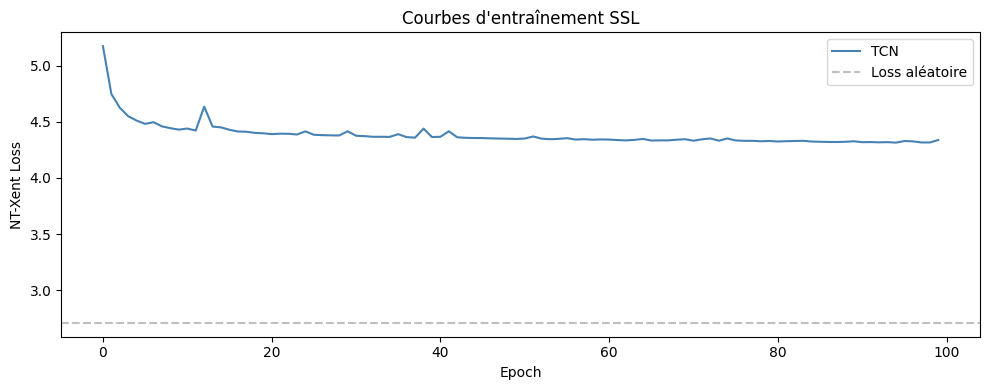

In [66]:


def train_ssl(model, loader, optimizer, scheduler, criterion, epochs, device):
    model.train()
    history = {"loss": []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        for x1, x2 in loader:
            x1, x2 = x1.to(device), x2.to(device)
            
            # Forward
            _, z1 = model(x1)
            _, z2 = model(x2)
            loss  = criterion(z1, z2)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        epoch_loss /= len(loader)
        history["loss"].append(epoch_loss)
        #scheduler.step()
        
        if (epoch + 1) % 1 == 0:
            #print(f"Epoch [{epoch+1:3d}/{epochs}] — Loss: {epoch_loss:.4f} "
            #      f"— LR: {scheduler.get_last_lr()[0]:.6f}")
            print(f"Epoch [{epoch+1:3d}/{epochs}] — Loss: {epoch_loss:.4f} "
                  f"— LR: 3e-3")

    return history



# --- Entraînement TCN ---
print("=" * 50)
print("SSL — TCN")
print("=" * 50)

tcn_model = SimCLRModel(tcn, CONFIG["d_model"], CONFIG["proj_dim"]).to(device)
optimizer = torch.optim.AdamW(tcn_model.parameters(), lr=3e-3,
                               weight_decay=1e-4)
'''scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-3,
    epochs=CONFIG["ssl_epochs"],
    steps_per_epoch=len(ssl_loader)
)'''

history_tcn_ssl = train_ssl(
    tcn_model, ssl_loader, optimizer, scheduler,
    criterion, CONFIG["ssl_epochs"], device
)

'''
# --- Entraînement PatchTST ---
print("\n" + "=" * 50)
print("SSL — PatchTST")
print("=" * 50)

patchtst_model = SimCLRModel(patchtst, CONFIG["d_model"], CONFIG["proj_dim"]).to(device)
optimizer = torch.optim.AdamW(patchtst_model.parameters(), lr=3e-3,
                               weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["ssl_epochs"]
)

history_patchtst_ssl = train_ssl(
    patchtst_model, ssl_loader, optimizer, scheduler,
    criterion, CONFIG["ssl_epochs"], device
)'''

# --- Visualisation des courbes de loss ---
plt.figure(figsize=(10, 4))
plt.plot(history_tcn_ssl["loss"],     label="TCN",      color="steelblue")
#plt.plot(history_patchtst_ssl["loss"], label="PatchTST", color="coral")
plt.axhline(y=2.708, color="gray", linestyle="--", alpha=0.5, label="Loss aléatoire")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("Courbes d'entraînement SSL")
plt.legend()
plt.tight_layout()
plt.show()

# 8bis - Entraînement sur toutes les données

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SSL sur le dataset COMPLET (87 553 signaux) sans rééquilibrage
ssl_dataset_full = ECGSSLDataset(X_train)  # dataset original complet
ssl_loader_full  = DataLoader(
    ssl_dataset_full,
    batch_size = CONFIG["ssl_batch_size"],
    shuffle    = True,
    num_workers= 2,
    pin_memory = True
)

print(f"SSL batches (full) : {len(ssl_loader_full)}")
# Attendu : ~342 batches vs 84 avant

# Relance TCN avec le nouveau loader
tcn = TCNEncoder(in_channels=1, channels=CONFIG["tcn_channels"],
                 n_layers=CONFIG["tcn_layers"], kernel_size=CONFIG["tcn_kernel"],
                 d_model=CONFIG["d_model"]).to(device)
tcn_model     = SimCLRModel(tcn, CONFIG["d_model"], CONFIG["proj_dim"]).to(device)
optimizer_tcn = torch.optim.AdamW(tcn_model.parameters(), lr=3e-3, weight_decay=1e-4)

history_tcn_ssl = train_ssl(
    tcn_model, ssl_loader_full, optimizer_tcn,scheduler,
    criterion, CONFIG["ssl_epochs"], device
)

SSL batches (full) : 343
Epoch [  1/100] — Loss: 4.7820 — LR: 3e-3
Epoch [  2/100] — Loss: 4.4862 — LR: 3e-3
Epoch [  3/100] — Loss: 4.4412 — LR: 3e-3
Epoch [  4/100] — Loss: 4.4235 — LR: 3e-3
Epoch [  5/100] — Loss: 4.4073 — LR: 3e-3
Epoch [  6/100] — Loss: 4.3944 — LR: 3e-3
Epoch [  7/100] — Loss: 4.3859 — LR: 3e-3
Epoch [  8/100] — Loss: 4.3762 — LR: 3e-3
Epoch [  9/100] — Loss: 4.3689 — LR: 3e-3
Epoch [ 10/100] — Loss: 4.3638 — LR: 3e-3
Epoch [ 11/100] — Loss: 4.3580 — LR: 3e-3
Epoch [ 12/100] — Loss: 4.3553 — LR: 3e-3
Epoch [ 13/100] — Loss: 4.3538 — LR: 3e-3
Epoch [ 14/100] — Loss: 4.3479 — LR: 3e-3
Epoch [ 15/100] — Loss: 4.3459 — LR: 3e-3
Epoch [ 16/100] — Loss: 4.3439 — LR: 3e-3
Epoch [ 17/100] — Loss: 4.3393 — LR: 3e-3
Epoch [ 18/100] — Loss: 4.3386 — LR: 3e-3
Epoch [ 19/100] — Loss: 4.3377 — LR: 3e-3
Epoch [ 20/100] — Loss: 4.3372 — LR: 3e-3
Epoch [ 21/100] — Loss: 4.3328 — LR: 3e-3
Epoch [ 22/100] — Loss: 4.3309 — LR: 3e-3
Epoch [ 23/100] — Loss: 4.3302 — LR: 3e-3
Epoch [ 2

KeyboardInterrupt: 

# 9 - Linear Probing


In [33]:
class LinearProbe(nn.Module):
    def __init__(self, encoder, d_model=128, n_classes=5):
        super().__init__()
        self.encoder = encoder
        # Gèle l'encodeur
        for param in self.encoder.parameters():
            param.requires_grad = False
        # Seule la couche linéaire est entraînable
        self.classifier = nn.Linear(d_model, n_classes)
    
    def forward(self, x):
        with torch.no_grad():
            h = self.encoder(x)
        return self.classifier(h)


def train_supervised(model, train_loader, val_loader,
                     optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    history   = {"train_loss": [], "val_f1": []}
    
    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        
        # --- Validation ---
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y   = x.to(device), y.to(device)
                logits = model(x)
                preds  = logits.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        
        val_f1 = f1_score(all_labels, all_preds, average="macro")
        history["train_loss"].append(train_loss)
        history["val_f1"].append(val_f1)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] — "
                  f"Loss: {train_loss:.4f} | Val F1 macro: {val_f1:.4f}")
    
    return history


def evaluate(model, loader, device):
    """Évaluation finale sur le test set."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            preds  = model(x).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    print("\n=== Rapport de classification ===")
    print(classification_report(all_labels, all_preds,
                                 target_names=list(CLASS_NAMES.values())))
    
    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES.values(),
                yticklabels=CLASS_NAMES.values())
    plt.title("Matrice de confusion")
    plt.ylabel("Vrai label")
    plt.xlabel("Prédit")
    plt.tight_layout()
    plt.show()
    
    return f1_score(all_labels, all_preds, average="macro")


# Linear Probing TCN 
print("=" * 50)
print("LINEAR PROBING — TCN")
print("=" * 50)

lp_tcn = LinearProbe(tcn_model.encoder,
                     CONFIG["d_model"], CONFIG["n_classes"]).to(device)
optimizer_lp = torch.optim.AdamW(
    lp_tcn.classifier.parameters(),  # seulement le classifieur
    lr=1e-3, weight_decay=1e-4
)

history_lp_tcn = train_supervised(
    lp_tcn, train_loader, val_loader,
    optimizer_lp, CONFIG["ft_epochs"], device
)

f1_lp_tcn = evaluate(lp_tcn, test_loader, device)
print(f"\nF1 macro test — Linear Probing TCN : {f1_lp_tcn:.4f}")

LINEAR PROBING — TCN
Epoch [  5/50] — Loss: 0.7115 | Val F1 macro: 0.7541
Epoch [ 10/50] — Loss: 0.6916 | Val F1 macro: 0.7625
Epoch [ 15/50] — Loss: 0.6699 | Val F1 macro: 0.7513
Epoch [ 20/50] — Loss: 0.6591 | Val F1 macro: 0.7703
Epoch [ 25/50] — Loss: 0.6538 | Val F1 macro: 0.7744
Epoch [ 30/50] — Loss: 0.6310 | Val F1 macro: 0.7745
Epoch [ 35/50] — Loss: 0.6235 | Val F1 macro: 0.7774
Epoch [ 40/50] — Loss: 0.6227 | Val F1 macro: 0.7756
Epoch [ 45/50] — Loss: 0.6229 | Val F1 macro: 0.7857
Epoch [ 50/50] — Loss: 0.6200 | Val F1 macro: 0.7887

=== Rapport de classification ===


AttributeError: 'list' object has no attribute 'values'


=== Rapport de classification ===
                   precision    recall  f1-score   support

       Normal (N)       0.98      0.62      0.76     18117
        Supra (S)       0.13      0.69      0.21       556
Ventriculaire (V)       0.35      0.80      0.49      1448
       Fusion (F)       0.08      0.83      0.14       162
      Inconnu (Q)       0.65      0.93      0.76      1608

         accuracy                           0.66     21891
        macro avg       0.44      0.77      0.47     21891
     weighted avg       0.88      0.66      0.72     21891



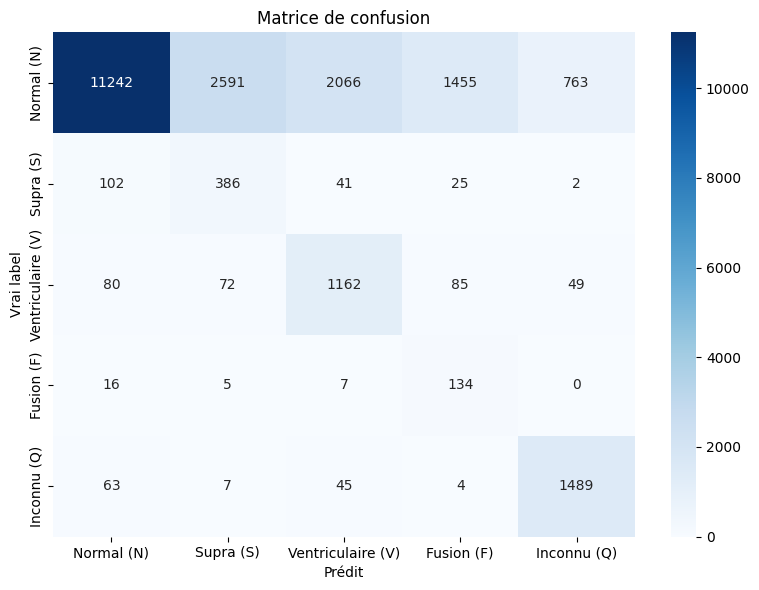


F1 macro test — Linear Probing TCN : 0.4730


In [38]:
CLASS_NAMES = {
    0: "Normal (N)",
    1: "Supra (S)", 
    2: "Ventriculaire (V)",
    3: "Fusion (F)",
    4: "Inconnu (Q)"
}

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            preds  = model(x).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    print("\n=== Rapport de classification ===")
    print(classification_report(all_labels, all_preds,
                                 target_names=[CLASS_NAMES[i] for i in range(5)]))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[CLASS_NAMES[i] for i in range(5)],
                yticklabels=[CLASS_NAMES[i] for i in range(5)])
    plt.title("Matrice de confusion")
    plt.ylabel("Vrai label")
    plt.xlabel("Prédit")
    plt.tight_layout()
    plt.show()
    
    return f1_score(all_labels, all_preds, average="macro")


f1_lp_tcn = evaluate(lp_tcn, test_loader, device)
print(f"\nF1 macro test — Linear Probing TCN : {f1_lp_tcn:.4f}")

# 10 - Fine Tuning Complet --> Supervised fine tuning

Class weights :
  Classe 0 (Normal (N)) : 0.2063
  Classe 1 (Supra (S)) : 1.1778
  Classe 2 (Ventriculaire (V)) : 0.7299
  Classe 3 (Fusion (F)) : 2.1934
  Classe 4 (Inconnu (Q)) : 0.6925
FINE-TUNING — TCN
Epoch [  5/50] — Loss: 0.4158 | Val F1 macro: 0.7104
Epoch [ 10/50] — Loss: 0.3754 | Val F1 macro: 0.7538
Epoch [ 15/50] — Loss: 0.3418 | Val F1 macro: 0.7630
Epoch [ 20/50] — Loss: 0.3424 | Val F1 macro: 0.7761
Epoch [ 25/50] — Loss: 0.3211 | Val F1 macro: 0.7943
Epoch [ 30/50] — Loss: 0.3093 | Val F1 macro: 0.7972
Epoch [ 35/50] — Loss: 0.3062 | Val F1 macro: 0.8100
Epoch [ 40/50] — Loss: 0.3266 | Val F1 macro: 0.8170
Epoch [ 45/50] — Loss: 0.2965 | Val F1 macro: 0.8158
Epoch [ 50/50] — Loss: 0.2935 | Val F1 macro: 0.8184

=== Rapport de classification ===
                   precision    recall  f1-score   support

       Normal (N)       1.00      0.48      0.64     18117
        Supra (S)       0.09      0.90      0.16       556
Ventriculaire (V)       0.48      0.85      0.61   

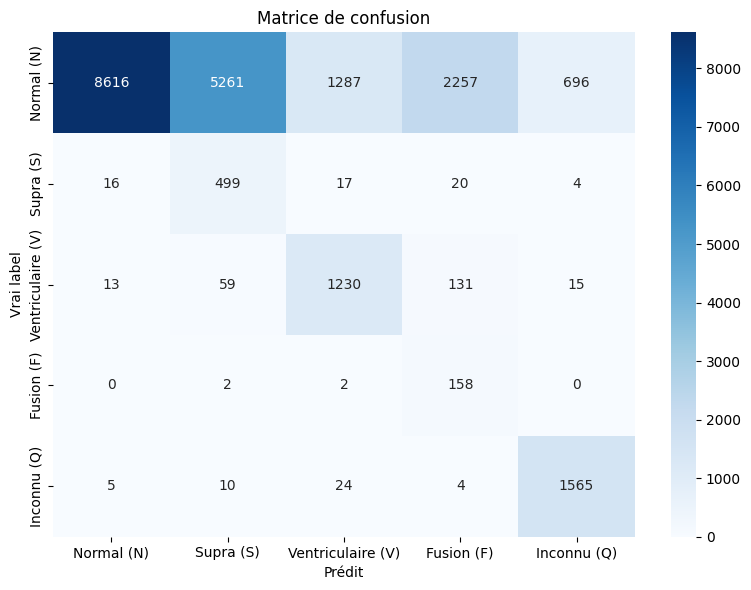


F1 macro test — Fine-tuning TCN : 0.4669

BASELINE — TCN supervisé from scratch
Epoch [  5/50] — Loss: 0.6328 | Val F1 macro: 0.6042
Epoch [ 10/50] — Loss: 0.4208 | Val F1 macro: 0.6572
Epoch [ 15/50] — Loss: 0.3539 | Val F1 macro: 0.6605
Epoch [ 20/50] — Loss: 0.3390 | Val F1 macro: 0.6752
Epoch [ 25/50] — Loss: 0.3427 | Val F1 macro: 0.6595
Epoch [ 30/50] — Loss: 0.3057 | Val F1 macro: 0.6955
Epoch [ 35/50] — Loss: 0.2877 | Val F1 macro: 0.4187
Epoch [ 40/50] — Loss: 0.2809 | Val F1 macro: 0.6694
Epoch [ 45/50] — Loss: 0.4040 | Val F1 macro: 0.6571
Epoch [ 50/50] — Loss: 0.3298 | Val F1 macro: 0.7026

=== Rapport de classification ===
                   precision    recall  f1-score   support

       Normal (N)       0.99      0.08      0.15     18117
        Supra (S)       0.04      0.96      0.07       556
Ventriculaire (V)       0.90      0.76      0.82      1448
       Fusion (F)       0.06      0.96      0.12       162
      Inconnu (Q)       0.61      0.96      0.75      1608

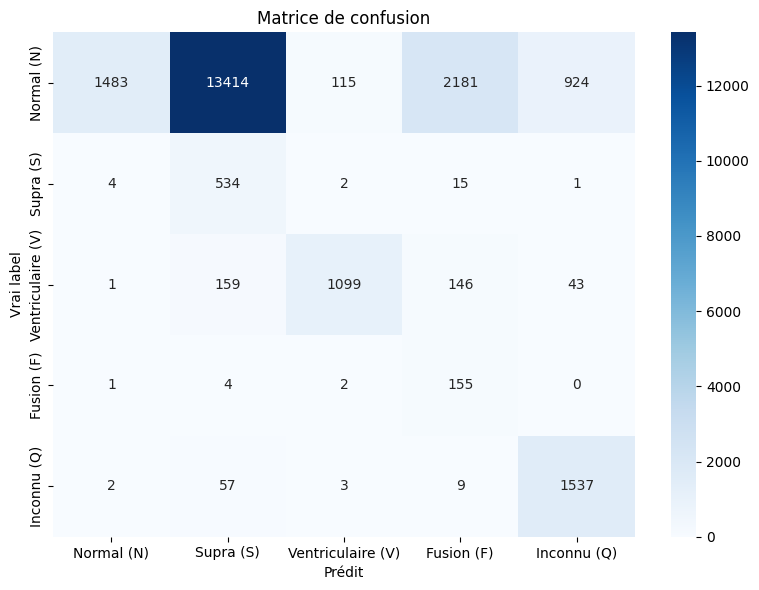


F1 macro test — Baseline from scratch : 0.3822

COMPARAISON FINALE
Linear Probing TCN    : 0.4730
Fine-tuning TCN (SSL) : 0.4669
Baseline from scratch : 0.3822


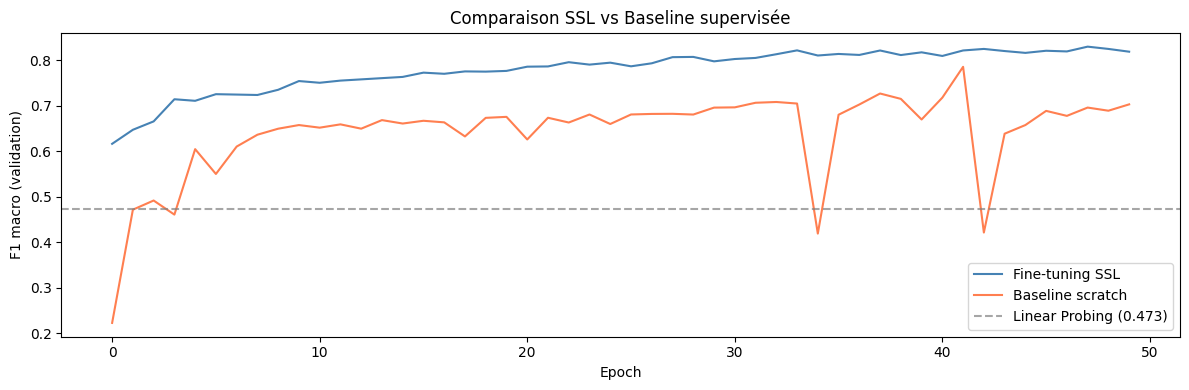

In [40]:


class FineTunedModel(nn.Module):
    def __init__(self, encoder, d_model=128, n_classes=5):
        super().__init__()
        self.encoder    = encoder  # encodeur dégelé
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )
    
    def forward(self, x):
        h = self.encoder(x)
        return self.classifier(h)


# Class weights pour corriger le prior shift 
class_counts = np.array([72470, 2223, 5788, 641, 6431])
class_weights = 1.0 / np.sqrt(class_counts)
class_weights = class_weights / class_weights.sum() * 5
criterion_ft  = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
)


print("Class weights :")
for i, w in enumerate(class_weights):
    print(f"  Classe {i} ({CLASS_NAMES[i]}) : {w:.4f}")


# --- Fine-tuning TCN ---
print("=" * 50)
print("FINE-TUNING — TCN")
print("=" * 50)

ft_tcn = FineTunedModel(tcn_model.encoder,
                        CONFIG["d_model"], CONFIG["n_classes"]).to(device)

# Encodeur avec LR réduit, classifieur avec LR normal
optimizer_ft = torch.optim.AdamW([
    {"params": ft_tcn.encoder.parameters(),    "lr": 1e-4},
    {"params": ft_tcn.classifier.parameters(), "lr": 1e-3}
], weight_decay=1e-4)

def train_finetuning(model, train_loader, val_loader,
                     optimizer, criterion, epochs, device):
    history = {"train_loss": [], "val_f1": []}
    
    for epoch in range(epochs):
        # Train 
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y   = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        
        # Validation 
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y   = x.to(device), y.to(device)
                preds  = model(x).argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        
        val_f1 = f1_score(all_labels, all_preds, average="macro")
        history["train_loss"].append(train_loss)
        history["val_f1"].append(val_f1)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] — "
                  f"Loss: {train_loss:.4f} | Val F1 macro: {val_f1:.4f}")
    
    return history


history_ft_tcn = train_finetuning(
    ft_tcn, train_loader, val_loader,
    optimizer_ft, criterion_ft, CONFIG["ft_epochs"], device
)

f1_ft_tcn = evaluate(ft_tcn, test_loader, device)
print(f"\nF1 macro test — Fine-tuning TCN : {f1_ft_tcn:.4f}")

# Baseline supervisée from scratch 
print("\n" + "=" * 50)
print("BASELINE — TCN supervisé from scratch")
print("=" * 50)

tcn_scratch = TCNEncoder(
    in_channels=1, channels=CONFIG["tcn_channels"],
    n_layers=CONFIG["tcn_layers"], kernel_size=CONFIG["tcn_kernel"],
    d_model=CONFIG["d_model"]
).to(device)

baseline_model = FineTunedModel(
    tcn_scratch, CONFIG["d_model"], CONFIG["n_classes"]
).to(device)

optimizer_base = torch.optim.AdamW(
    baseline_model.parameters(), lr=1e-3, weight_decay=1e-4
)

history_baseline = train_finetuning(
    baseline_model, train_loader, val_loader,
    optimizer_base, criterion_ft, CONFIG["ft_epochs"], device
)

f1_baseline = evaluate(baseline_model, test_loader, device)
print(f"\nF1 macro test — Baseline from scratch : {f1_baseline:.4f}")

# --- Comparaison finale ---
print("\n" + "=" * 50)
print("COMPARAISON FINALE")
print("=" * 50)
print(f"Linear Probing TCN    : {f1_lp_tcn:.4f}")
print(f"Fine-tuning TCN (SSL) : {f1_ft_tcn:.4f}")
print(f"Baseline from scratch : {f1_baseline:.4f}")

# --- Courbes de validation ---
plt.figure(figsize=(12, 4))
plt.plot(history_ft_tcn["val_f1"],   label="Fine-tuning SSL", color="steelblue")
plt.plot(history_baseline["val_f1"], label="Baseline scratch", color="coral")
plt.axhline(y=f1_lp_tcn, color="gray", linestyle="--",
            alpha=0.7, label=f"Linear Probing ({f1_lp_tcn:.3f})")
plt.xlabel("Epoch")
plt.ylabel("F1 macro (validation)")
plt.title("Comparaison SSL vs Baseline supervisée")
plt.legend()
plt.tight_layout()
plt.show()

Modèle et F1 macro : 
- Baseline supervisé (from scratch) : 0.3822
- Fine-tuning TCN (SSL) : 0.4669
- Linear Probing TCN (SSL): 0.4730


Le SSL apporte clairement de la valeur. Les deux variantes SSL (linear probing et fine-tuning) surpassent significativement la baseline supervisée (+0.09 de F1 macro), ce qui valide l'approche SimCLR sur les ECG. Le pré-entraînement sur les 87 553 signaux non équilibrés (section 8bis) a permis d'apprendre des représentations utiles.

La convergence SSL est correcte. La NT-Xent loss descend de ~5.1 à ~4.3 en 100 epochs sur le full dataset, ce qui indique que l'encodeur TCN apprend bien à distinguer les vues augmentées.

**Le fine-tuning est moins bon que le linear probing (0.4669 vs 0.4730)**, ce qui est contre-intuitif. Cela suggère un overfitting ou une instabilité d'entraînement : le fine-tuning dégèle l'encodeur et corrompt les représentations SSL au lieu de les affiner. 

Le val F1 oscille (0.8170 à l'epoch 40, puis 0.8158 à l'epoch 45) alors que la loss continue de descendre — signe classique d'overfitting.

Le problème majeur : le déséquilibre test vs train. L'entraînement se fait sur un dataset rééquilibré (5000 par classe), mais le test conserve la distribution naturelle MIT-BIH (83% de classe Normal), même avec une répartition des poids dans la CrossEntropy